# **GRADED ASSIGNMENT 3 - Task 2**

This is a programming task dedicated to SVD.

First, make your own copy of the notebook (*File $\rightarrow$ Save a copy in Drive*) or download the notebook to your machine if you prefer to work locally (*File $\rightarrow$ Download*).

Then, implement your solutions to the tasks formulated in the notebook. You can add **code cells** to write some code and **text cells** in case you want to include additional explanations to your answers in plain English.

Finally, attach the link to thi snotebook the submission form. **Make sure that all the cells are executed and all relevant outputs are being printed out**.


## Image compression with SVD

We have seen that SVD allows one to decompose any $m \times n$ matrix $A$, into the product of the orthogonal matrices $U$ and $V$ and a "diagonal" matrix $\Sigma$:

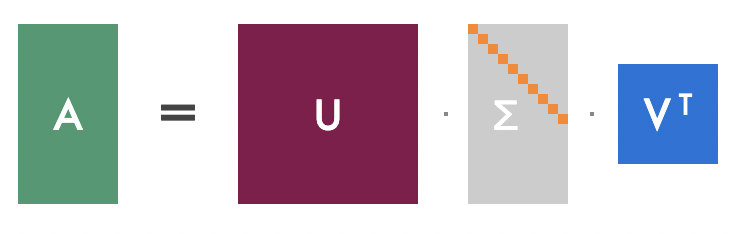

We have also discussed that we can *approximate* the original matrix $A$ by using only some parts of the matrices $U, V$ and $\Sigma$:

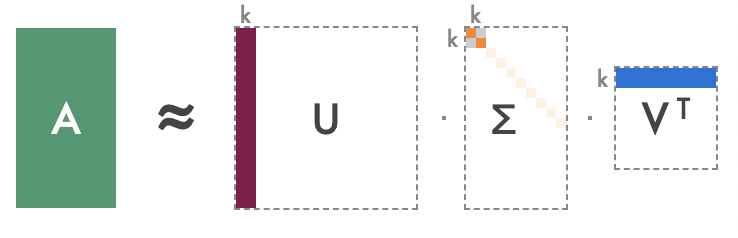

You can notice that this approximation can help us save quite a lot of space. Indeed, inspeat of storing $m \times n$ of the original values in A we now need to store only $m \times k + k + k \times n = k \times (m + n + 1)$ values. **Since images can be represented as matrices of pixel values, we can use this idea and compress images with SVD!**

Here are some videos that explain this idea and give some examples that you might want to watch before attempting the task:
- [SVD and Image Compression](https://youtu.be/DG7YTlGnCEo)
- [SVD: Image Compression in Python](https://youtu.be/H7qMMudo3e8)

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
%matplotlib inline

First, let's load the image into a $\texttt{numpy}$ array and display it.

You can use *any* image of your choice, or upload one of the sample images provided [in our repo](https://github.com/girafe-ai/math-basics-for-ai/tree/master/graded%20assignments/img).

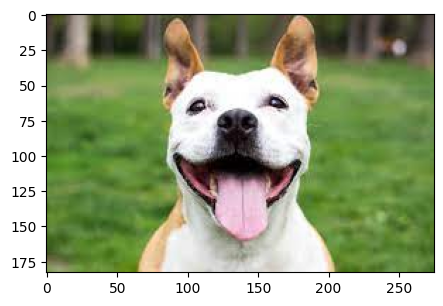

In [2]:

# Replace 'image_url' with the URL of the image you want to open
image_url = 'https://github.com/girafe-ai/math-basics-for-ai/raw/master/graded%20assignments/img/sample-images-svd/dog.jpeg'

# Send an HTTP GET request to the URL to download the image
response = requests.get(image_url)

if response.status_code == 200:
    # Open the image from the response content using Pillow
    img = Image.open(BytesIO(response.content))

    # Convert the Pillow Image to a numpy array for further processing
    img_rgb = np.array(img)

    # Now you can work with 'img_array' for SVD and compression
    plt.figure(figsize=(5, 10))
    plt.imshow(img_rgb)
    plt.show()
else:
    print("Failed to download the image")

Note how image is represented in the RGB format:

In [3]:
print(img_rgb.shape)
img_rgb

(183, 275, 3)


array([[[ 60,  43,  49],
        [ 61,  47,  47],
        [ 63,  49,  46],
        ...,
        [ 89,  78,  74],
        [ 89,  78,  74],
        [ 89,  78,  74]],

       [[ 63,  46,  52],
        [ 63,  49,  49],
        [ 66,  52,  49],
        ...,
        [ 90,  79,  75],
        [ 90,  79,  75],
        [ 90,  79,  75]],

       [[ 67,  50,  56],
        [ 67,  53,  53],
        [ 70,  56,  53],
        ...,
        [ 91,  80,  76],
        [ 91,  80,  76],
        [ 91,  80,  76]],

       ...,

       [[134, 152,  90],
        [135, 153,  91],
        [136, 154,  94],
        ...,
        [ 67, 107,  36],
        [ 66, 108,  34],
        [ 66, 108,  34]],

       [[130, 151,  86],
        [130, 152,  87],
        [133, 153,  90],
        ...,
        [ 66, 106,  35],
        [ 65, 107,  33],
        [ 65, 107,  33]],

       [[124, 147,  79],
        [123, 148,  80],
        [128, 150,  85],
        ...,
        [ 66, 106,  35],
        [ 65, 107,  33],
        [ 65, 107,  33]]

For simplicity, let's make our image black-and-white (this way, we'll only need to work with a single channel). We'll do this by averaging the signals from the red, green and blue channels for each pixel.

In [4]:
img_grayscale = np.mean(img_rgb, axis=-1)

Now, our image is represented as an $m \times n$ matrix:

In [5]:
print(img_grayscale.shape)
img_grayscale

(183, 275)


array([[ 50.66666667,  51.66666667,  52.66666667, ...,  80.33333333,
         80.33333333,  80.33333333],
       [ 53.66666667,  53.66666667,  55.66666667, ...,  81.33333333,
         81.33333333,  81.33333333],
       [ 57.66666667,  57.66666667,  59.66666667, ...,  82.33333333,
         82.33333333,  82.33333333],
       ...,
       [125.33333333, 126.33333333, 128.        , ...,  70.        ,
         69.33333333,  69.33333333],
       [122.33333333, 123.        , 125.33333333, ...,  69.        ,
         68.33333333,  68.33333333],
       [116.66666667, 117.        , 121.        , ...,  69.        ,
         68.33333333,  68.33333333]])

We can plot the grayscale image:

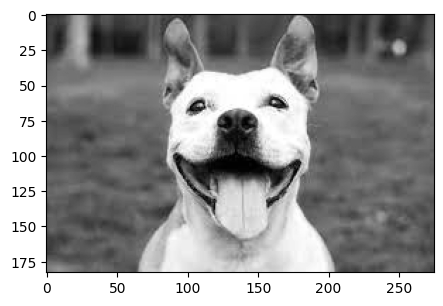

In [6]:
plt.figure(figsize=(5, 10))
plt.imshow(img_grayscale, cmap='gray')

Apply SVD on the image matrix $M$, decomposing it into the product of the orthogonal matrices $U$ and $V$ and a "diagonal" matrix $\Sigma$:

$$M_{m \times n} = U_{m \times m} \Sigma_{m \times n} V_{n \times n}^T$$

*You can use [$\texttt{np.linalg.svd()}$](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) to perform SVD.*


EXPLANATION:

Printing the entire matrices U, Sigma, and Vt in their raw form might be too extensive due to their dimensions. However, I deemed it best to print the shape and subset of the matrices to give you an idea of their structure:

In [7]:

# Perform SVD on the grayscale image
U, Sigma, Vt = np.linalg.svd(img_grayscale, full_matrices=False)

# U, Sigma, and Vt are the results of SVD
# U: Left singular vectors
# Sigma: Singular values
# Vt: Right singular vectors (transposed)

# You can print the shapes of U, Sigma, and Vt to verify the dimensions
print("Shape of U:", U.shape)
print("Shape of Sigma:", Sigma.shape)
print("Shape of Vt:", Vt.shape)

Shape of U: (183, 183)
Shape of Sigma: (183,)
Shape of Vt: (183, 275)


In [8]:

# Print a subset of the U, Sigma, and Vt matrices (e.g., the first 5 rows and columns)
print("Subset of U:")
print(U[:5, :5])

print("Subset of Sigma:")
print(Sigma[:5])

print("Subset of Vt:")
print(Vt[:5, :5])

Subset of U:
[[-0.04078837  0.01330577  0.08386843  0.03477118  0.0336646 ]
 [-0.04240158  0.0072578   0.08297268  0.01850309 -0.00713179]
 [-0.04316655  0.00278553  0.08417621  0.0119687  -0.01836651]
 [-0.04425951 -0.00267936  0.08556147 -0.00147661 -0.03527342]
 [-0.04565147 -0.00894661  0.08534494 -0.02083663 -0.05972029]]
Subset of Sigma:
[29183.73008658  5213.09848537  3824.53592072  3002.3772755
  2507.04152209]
Subset of Vt:
[[-0.04057196 -0.04069526 -0.04104693 -0.04129168 -0.04158565]
 [ 0.00693953  0.00768064  0.00867205  0.00982428  0.01079759]
 [ 0.0450671   0.04479629  0.04573666  0.04541283  0.04435428]
 [ 0.03902238  0.03802776  0.03709087  0.03617913  0.03594614]
 [-0.01108125 -0.01097163 -0.01064992 -0.00904817 -0.00604193]]


**(1 point)** Demonstrate how you can get your image matrix back as a product of $U$, $V$ and $\Sigma$ *(express image matrix $M$ as a product of the three matrices and plot the resulting image, making sure it's the same as before)*.

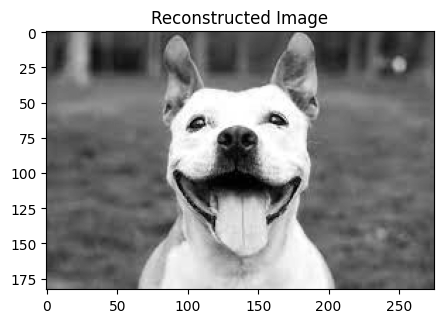

In [9]:

# Reconstruct the image from U, Sigma, and Vt
img_reconstructed = np.dot(U, np.dot(np.diag(Sigma), Vt))

# Plot the reconstructed image
plt.figure(figsize=(5, 10))
plt.imshow(img_reconstructed, cmap='gray')
plt.title("Reconstructed Image")
plt.show()

Now, let's compress the original image! Remember that with SVD, you can approximate the original  matrix by considering only $p$ of the hidden features:

$$M_{m \times n} \approx U_{m \times p} \Sigma_{p \times p} V_{n \times p}^T$$

**(2 points)** Try reconstructing the image by using only $5, 10, ..., 100$ hidden features. Plot what happens.

*Hint: use [$\texttt{plt.subplot()}$](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html) to place several images on the same plot.*

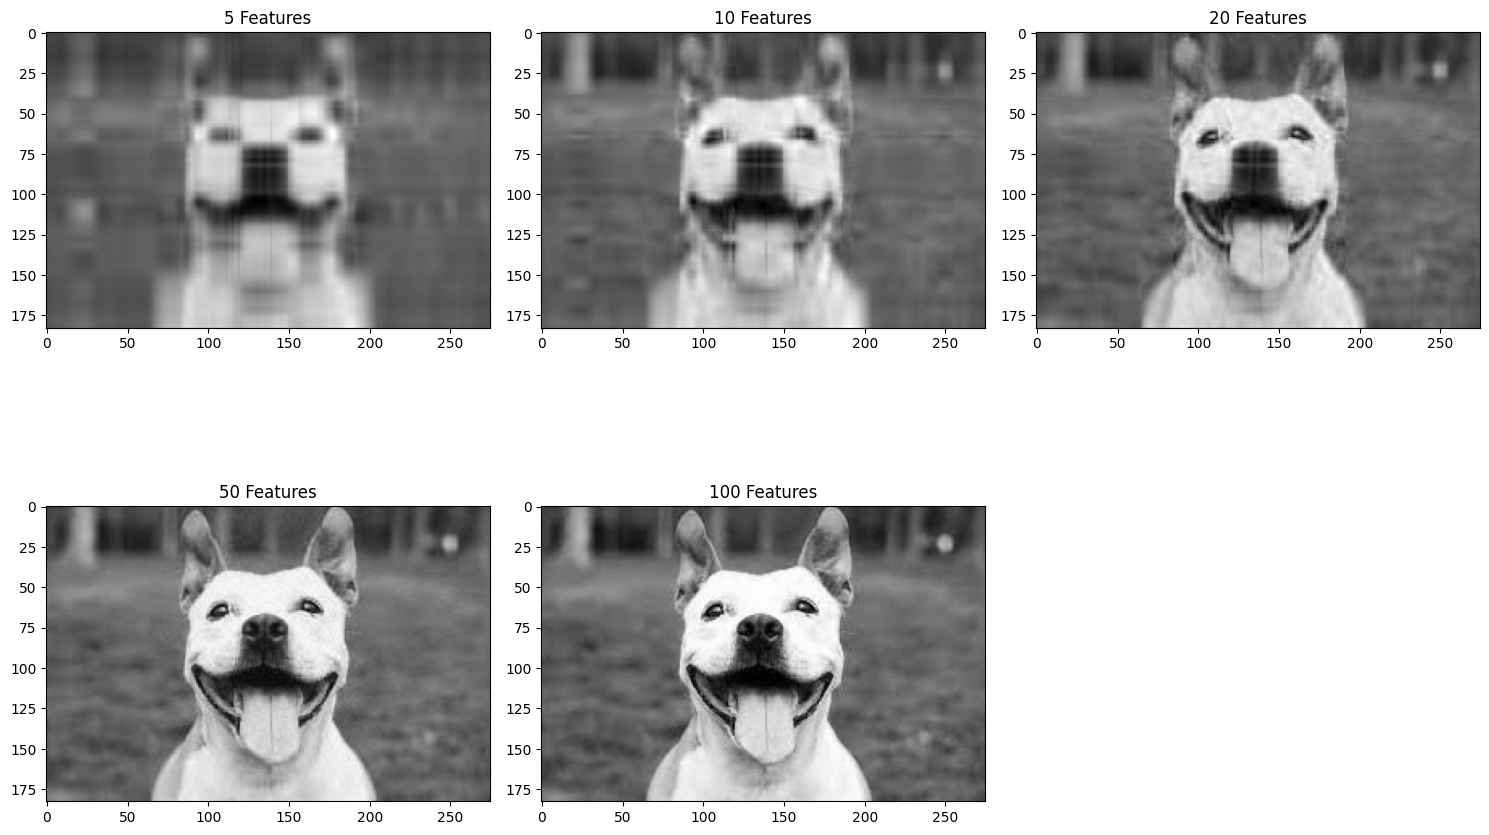

In [10]:

# List of the number of hidden features (singular values) to use
num_features_list = [5, 10, 20, 50, 100]

# Create a subplot to display multiple images
plt.figure(figsize=(15, 10))

for i, num_features in enumerate(num_features_list):
    # Reconstruct the image using a subset of singular values
    reconstructed_img = np.dot(U[:, :num_features], np.dot(np.diag(Sigma[:num_features]), Vt[:num_features, :]))

    # Set up the subplot
    plt.subplot(2, 3, i + 1)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f"{num_features} Features")

plt.tight_layout()
plt.show()